In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from pathlib import Path

In [2]:
def wavelength_to_rgb(wavelength, gamma=0.8):
    if wavelength < 380 or wavelength > 750:
        return (0.5, 0.5, 0.5)
    if 380 <= wavelength <= 440:
        attenuation = 0.3 + 0.7 * (wavelength - 380) / (440 - 380)
        R = ((-(wavelength - 440) / (440 - 380)) * attenuation) ** gamma
        G = 0.0
        B = (1.0 * attenuation) ** gamma
    elif 440 < wavelength <= 490:
        R = 0.0
        G = ((wavelength - 440) / (490 - 440)) ** gamma
        B = 1.0
    elif 490 < wavelength <= 510:
        R = 0.0
        G = 1.0
        B = (-(wavelength - 510) / (510 - 490)) ** gamma
    elif 510 < wavelength <= 580:
        R = ((wavelength - 510) / (580 - 510)) ** gamma
        G = 1.0
        B = 0.0
    elif 580 < wavelength <= 645:
        R = 1.0
        G = (-(wavelength - 645) / (645 - 580)) ** gamma
        B = 0.0
    elif 645 < wavelength <= 750:
        attenuation = 0.3 + 0.7 * (750 - wavelength) / (750 - 645)
        R = (1.0 * attenuation) ** gamma
        G = 0.0
        B = 0.0
    return (R, G, B)

def scatter_colored(df, col_Es1, col_f, title, xlab, ylab, xlim=None):
    d = df.dropna(subset=[col_Es1, col_f]).copy()
    if d.empty:
        return
    lam = 1239.841984 / d[col_Es1].values  # eV -> nm
    colors = [wavelength_to_rgb(w) for w in lam]
    fig, ax = plt.subplots(figsize=(6.6, 5.2), dpi=300)
    ax.scatter(d[col_Es1], d[col_f], c=colors, s=10)
    ax.set_title(title)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)
    if xlim is not None:
        ax.set_xlim(*xlim)
    return fig, ax

# study datasets

In [3]:
base_path = "plots_for_manuscript/training_and_generated/"

train = pd.read_csv(base_path + "combined_training_data.csv")
gen   = pd.read_csv(base_path + "generated_validation_data.csv")

In [4]:
print(f"Training data: {len(train)} entries")
print(f"Generated data: {len(gen)} entries")

Training data: 491128 entries
Generated data: 458 entries


In [5]:
# drop duplicates and then compute the len
train = train.drop_duplicates(subset=["smiles"])
gen = gen.drop_duplicates(subset=["smiles"])
print(f"Training data (after dropping duplicates): {len(train)} entries")
print(f"Generated data (after dropping duplicates): {len(gen)} entries")

Training data (after dropping duplicates): 491128 entries
Generated data (after dropping duplicates): 458 entries


# Study generation

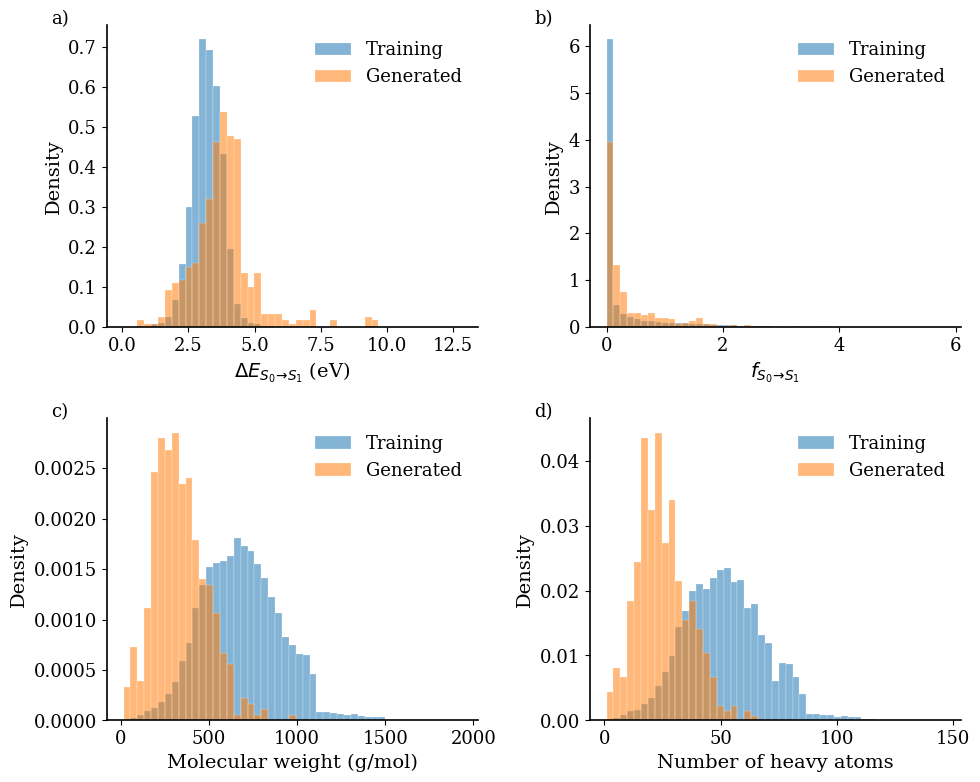

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

base_path = "plots_for_manuscript/training_and_generated/"

train = pd.read_csv(base_path + "combined_training_data.csv")
gen   = pd.read_csv(base_path + "generated_validation_data.csv")

plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 14,
    "legend.fontsize": 13,
    "axes.linewidth": 1.2
})

# change the labels so we use $\Delta E_{S_0\!\to\!S_1}$ (eV) and oscillator strength  $f_{S_0\!\to\!S_1}$
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.flatten()

def plot_hist(ax, data1, data2, xlabel):
    data1 = data1.dropna()
    data2 = data2.dropna()

    bins = np.linspace(
        min(data1.min(), data2.min()),
        max(data1.max(), data2.max()),
        50
    )

    ax.hist(
        data1,
        bins=bins,
        density=True,
        alpha=0.55,
        label="Training",
        edgecolor="white",
        linewidth=0.3
    )

    ax.hist(
        data2,
        bins=bins,
        density=True,
        alpha=0.55,
        label="Generated",
        edgecolor="white",
        linewidth=0.3
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.legend(frameon=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plot_hist(
    axes[0],
    train["absorption"],
    gen["E_S1_SOC(eV)"],
    "$\\Delta E_{S_0\\!\\to\\!S_1}$ (eV)"
)

plot_hist(
    axes[1],
    train["strength"],
    gen["osc_S1_SOC"],
    "$f_{S_0\\!\\to\\!S_1}$"
)

plot_hist(
    axes[2],
    train["molecular_weight"],
    gen["molecular_weight"],
    "Molecular weight (g/mol)"
)

plot_hist(
    axes[3],
    train["heavy_atoms"],
    gen["heavy_atoms"],
    "Number of heavy atoms"
)

labels = ["a)", "b)", "c)", "d)"]
for ax, lab in zip(axes, labels):
    ax.text(
        -0.15, 1.05, lab,
        transform=ax.transAxes,
        fontsize=13,
        va="top"
    )

plt.tight_layout()

plt.savefig("plots_for_manuscript/training_and_generated/training_vs_generated_distributions_panelled.pdf", bbox_inches="tight")
plt.savefig("plots_for_manuscript/training_and_generated/training_vs_generated_distributions_panelled.svg", bbox_inches="tight")
plt.savefig("plots_for_manuscript/training_and_generated/training_vs_generated_distributions_panelled.png", dpi=600, bbox_inches="tight")

plt.show()
plt.close()

# Now the absorption vs oscillator strength plots

In [32]:
gen_val_data = pd.read_csv("plots_for_manuscript/training_and_generated/generated_validation_data.csv")
print(gen_val_data.head())
train = pd.read_csv("plots_for_manuscript/validation_optical_properties/training_computed_df_all.csv")
print(train.head())

print(f"Training set: {len(train)} entries")
print(f"Generated validation set: {len(gen_val_data)} entries")

       mol                                             smiles  E_S1(eV)  \
0  mol0001  CC1(C)c2ccccc2N(c2ccc(/C=C(/C#N)C(=O)O)cc2)c2c...  3.484232   
1  mol0004  c1ccc(N(c2ccccc2)c2ccc3c(c2)Oc2ccccc2N3c2cccc(...  3.921178   
2  mol0005                         Cc1cc(-c2ccccc2)c2ccccc2c1  4.597870   
3  mol0006  CCCC1(C)c2cc(N3c4ccccc4Oc4ccccc43)ccc2-c2ccc(N...  4.148900   
4  mol0007  CCCC1(C)c2cc(N3c4ccccc4C(C)(C)c4ccccc43)ccc2-c...  4.536639   

   wl_S1(nm)    osc_S1  E_S2(eV)  wl_S2(nm)    osc_S2  E_S3(eV)  wl_S3(nm)  \
0      355.8  1.555150  4.671025      265.4  0.004173  5.032897      246.3   
1      316.2  0.221071  4.145382      299.1  0.280226  4.472756      277.2   
2      269.7  0.076768  4.721513      262.6  0.280983  5.423316      228.6   
3      298.8  0.047076  4.192487      295.7  0.048159  4.373187      283.5   
4      273.3  0.007779  4.555223      272.2  0.019595  4.620552      268.3   

   ...  osc_S2_SOC  E_S3_SOC(eV)  wl_S3_SOC(nm)  osc_S3_SOC  HOMO(eV)  \
0  ... 

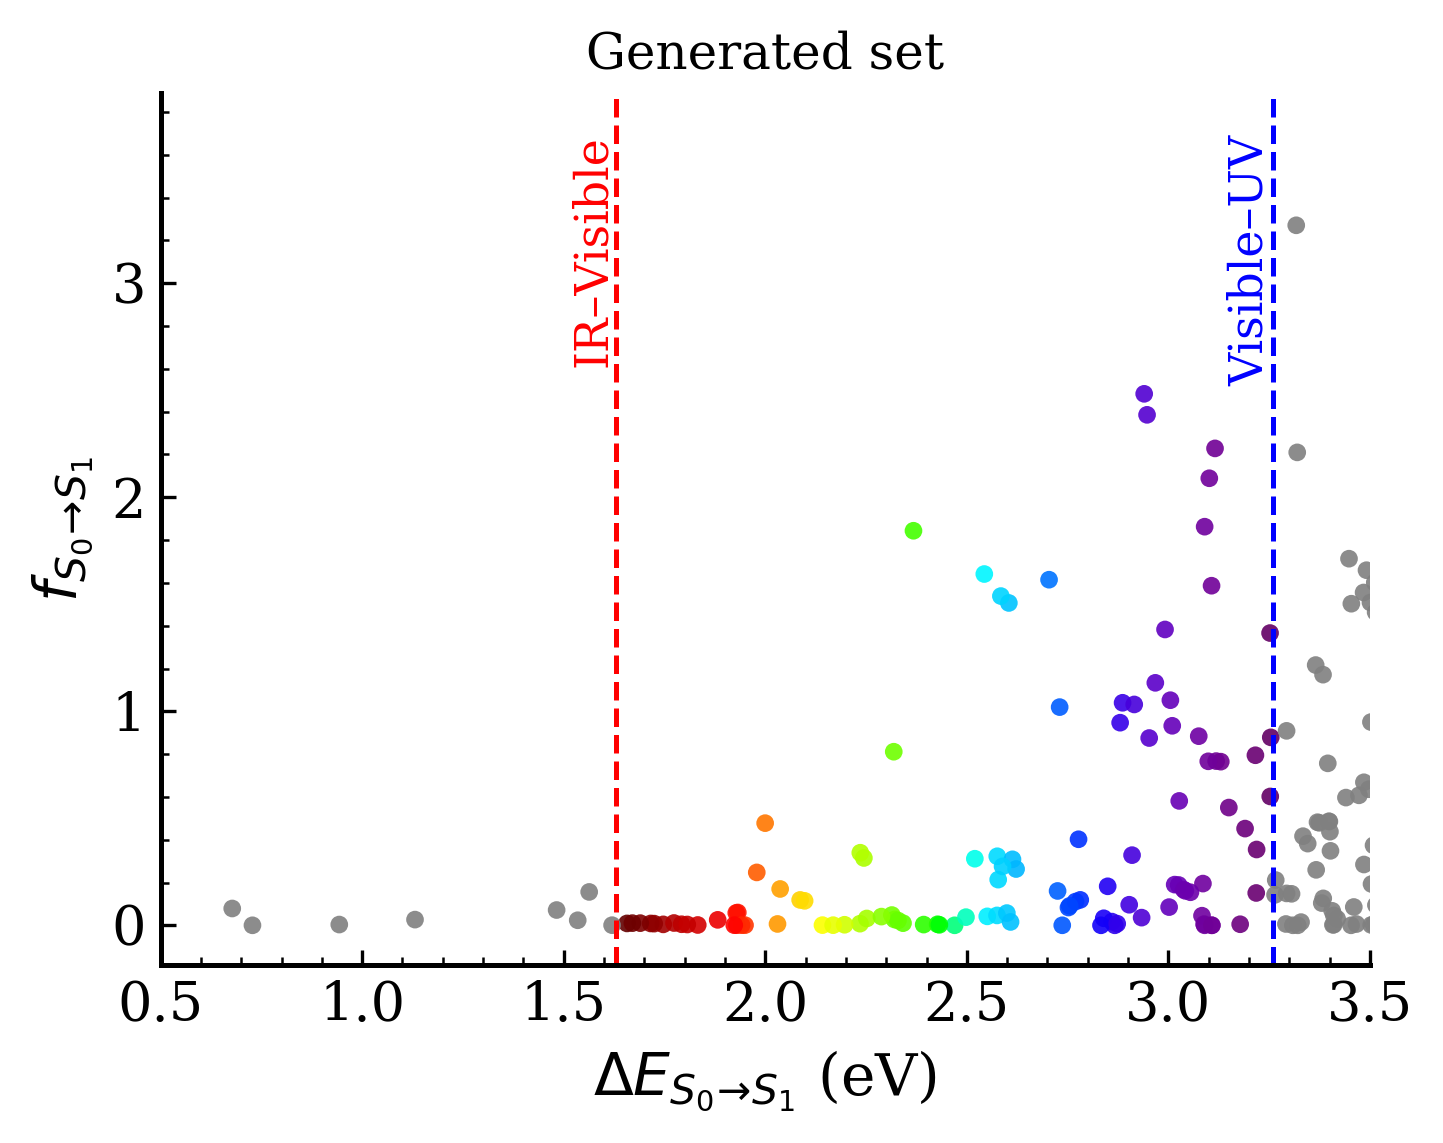

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
gen_val_data = pd.read_csv(
    "plots_for_manuscript/training_and_generated/generated_validation_data.csv"
)

plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True
})

def scatter_colored(df, col_Es1, col_f, title, xlab, ylab, xlim=None):
    d = df.dropna(subset=[col_Es1, col_f]).copy()
    lam = 1239.841984 / d[col_Es1].values  # eV → nm
    colors = [wavelength_to_rgb(w) for w in lam]

    fig, ax = plt.subplots(figsize=(5, 4), dpi=300)

    ax.scatter(
        d[col_Es1],
        d[col_f],
        c=colors,
        s=18,
        alpha=0.9,
        edgecolors="none"
    )

    ax.set_title(title)
    ax.set_xlabel(xlab)
    ax.set_ylabel(ylab)

    if xlim is not None:
        ax.set_xlim(*xlim)

    return fig, ax


# ---- Plot (panel b)
fig, ax = scatter_colored(
    gen_val_data,
    col_Es1="E_S1_SOC(eV)",
    col_f="osc_S1_SOC",
    title="Generated set",
    xlab=r"$\Delta E_{S_0\!\to\!S_1}$ (eV)",
    ylab=r"$f_{S_0\!\to\!S_1}$",
    xlim=(0.5, 3.5)
)

# Vertical region boundaries
ax.axvline(1.63, color="red", linestyle="--", linewidth=1.2)
ax.axvline(3.26, color="blue", linestyle="--", linewidth=1.2)

# Labels on lines
ymax = ax.get_ylim()[1]

ax.text(
    1.63, ymax * 0.95, "IR–Visible",
    color="red",
    rotation=90,
    va="top",
    ha="right",
    fontsize=11
)

ax.text(
    3.26, ymax * 0.95, "Visible–UV",
    color="blue",
    rotation=90,
    va="top",
    ha="right",
    fontsize=11
)

# Clean style
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "plots_for_manuscript/training_and_generated/generated_scatter_rgb.pdf",
    bbox_inches="tight"
)


plt.show()
plt.close()

/tmp/ipykernel_23154/2122578601.py:47: RuntimeWarning: divide by zero encountered in divide
  wavelength = 1239.841984 / data[col_E].values


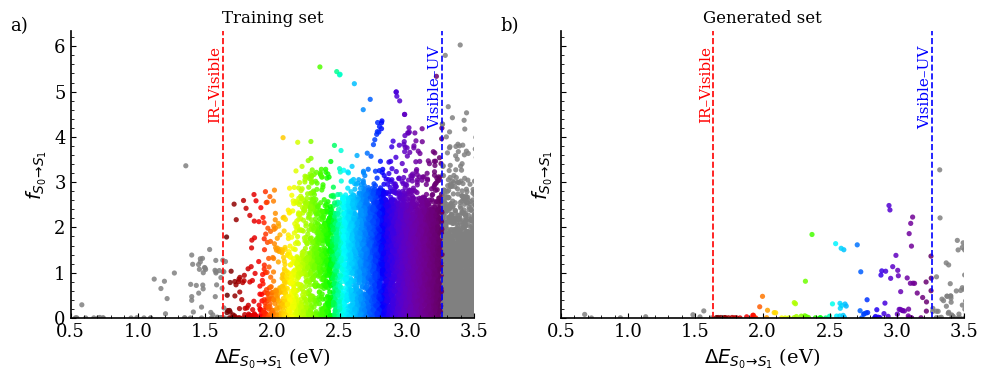

In [38]:


base_path = "plots_for_manuscript/training_and_generated/"

train_filtered = train[train["wb97_osc1"] <= 10]


out_dir = Path("plots_for_manuscript/validation_optical_properties")
out_dir.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True
})

def add_region_lines(ax):
    ax.axvline(1.63, color="red", linestyle="--", linewidth=1.2)
    ax.axvline(3.26, color="blue", linestyle="--", linewidth=1.2)

    ymax = ax.get_ylim()[1]

    ax.text(
        1.63, ymax * 0.95, "IR–Visible",
        color="red",
        rotation=90,
        va="top",
        ha="right",
        fontsize=11
    )

    ax.text(
        3.26, ymax * 0.95, "Visible–UV",
        color="blue",
        rotation=90,
        va="top",
        ha="right",
        fontsize=11
    )

def scatter_panel(ax, df, col_E, col_f, title):
    data = df[[col_E, col_f]].dropna().copy()

    wavelength = 1239.841984 / data[col_E].values
    colors = [wavelength_to_rgb(w) for w in wavelength]

    ax.scatter(
        data[col_E],
        data[col_f],
        c=colors,
        s=14,
        alpha=0.85,
        edgecolors="none"
    )

    ax.set_title(title)
    ax.set_xlabel(r"$\Delta E_{S_0\!\to\!S_1}$ (eV)")
    ax.set_ylabel(r"$f_{S_0\!\to\!S_1}$")
    ax.set_xlim(0.5, 3.5)
    ax.set_ylim(bottom=0)

    add_region_lines(ax)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

scatter_panel(
    axes[0],
    train_filtered,
    col_E="wb97_vert1",
    col_f="wb97_osc1",
    title="Training set"
)

scatter_panel(
    axes[1],
    gen_val_data,
    col_E="E_S1_SOC(eV)",
    col_f="osc_S1_SOC",
    title="Generated set"
)

labels = ["a)", "b)"]
for ax, lab in zip(axes, labels):
    ax.text(
        -0.15, 1.05, lab,
        transform=ax.transAxes,
        fontsize=13,
        va="top"
    )

plt.tight_layout()

plt.savefig(out_dir / "training_vs_generated_scatter_panelled.pdf", bbox_inches="tight")
plt.savefig(out_dir / "training_vs_generated_scatter_panelled.svg", bbox_inches="tight")
plt.savefig(out_dir / "training_vs_generated_scatter_panelled.png", dpi=600, bbox_inches="tight")

plt.show()
plt.close()

In [42]:
# Now with all the training data (still filtering out the very high oscillator strengths)

train_all_p = "plots_for_manuscript/training_and_generated/combined_training_data.csv"
train_all = pd.read_csv(train_all_p)
train_all_filtered = train_all[train_all["strength"] <= 10]

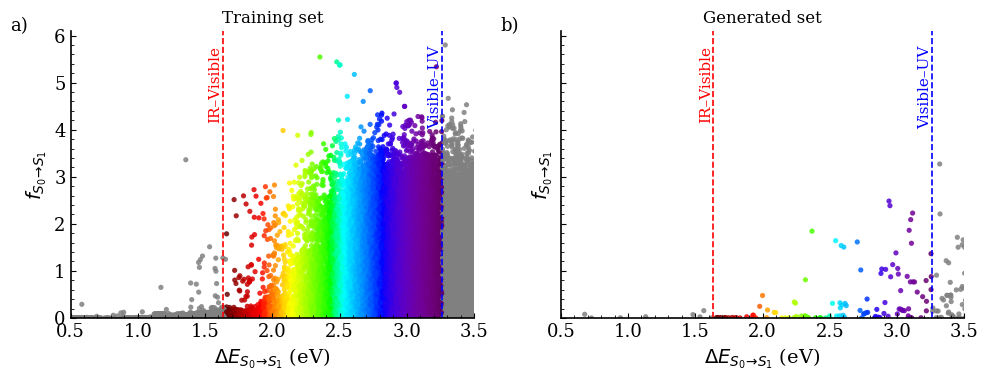

In [43]:


base_path = "plots_for_manuscript/training_and_generated/"

train_filtered = train[train["wb97_osc1"] <= 10]


out_dir = Path("plots_for_manuscript/validation_optical_properties")
out_dir.mkdir(parents=True, exist_ok=True)

plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True
})

def add_region_lines(ax):
    ax.axvline(1.63, color="red", linestyle="--", linewidth=1.2)
    ax.axvline(3.26, color="blue", linestyle="--", linewidth=1.2)

    ymax = ax.get_ylim()[1]

    ax.text(
        1.63, ymax * 0.95, "IR–Visible",
        color="red",
        rotation=90,
        va="top",
        ha="right",
        fontsize=11
    )

    ax.text(
        3.26, ymax * 0.95, "Visible–UV",
        color="blue",
        rotation=90,
        va="top",
        ha="right",
        fontsize=11
    )

def scatter_panel(ax, df, col_E, col_f, title):
    data = df[[col_E, col_f]].dropna().copy()

    wavelength = 1239.841984 / data[col_E].values
    colors = [wavelength_to_rgb(w) for w in wavelength]

    ax.scatter(
        data[col_E],
        data[col_f],
        c=colors,
        s=14,
        alpha=0.85,
        edgecolors="none"
    )

    ax.set_title(title)
    ax.set_xlabel(r"$\Delta E_{S_0\!\to\!S_1}$ (eV)")
    ax.set_ylabel(r"$f_{S_0\!\to\!S_1}$")
    ax.set_xlim(0.5, 3.5)
    ax.set_ylim(bottom=0)

    add_region_lines(ax)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharex=True, sharey=True)

scatter_panel(
    axes[0],
    train_all_filtered,
    col_E="absorption",
    col_f="strength",
    title="Training set"
)

scatter_panel(
    axes[1],
    gen_val_data,
    col_E="E_S1_SOC(eV)",
    col_f="osc_S1_SOC",
    title="Generated set"
)

labels = ["a)", "b)"]
for ax, lab in zip(axes, labels):
    ax.text(
        -0.15, 1.05, lab,
        transform=ax.transAxes,
        fontsize=13,
        va="top"
    )

plt.tight_layout()

plt.savefig(out_dir / "training_vs_generated_scatter_all_trainingset_panelled.pdf", bbox_inches="tight")


plt.show()
plt.close()

In [30]:
train

,smiles,homo,lumo,wb97_vert1,wb97_vert2,wb97_vert3,wb97_vert4,wb97_vert5,wb97_osc1,wb97_osc2,...,wb97_osc4,wb97_osc5,wb97_transdip1,wb97_transdip2,wb97_transdip3,wb97_transdip4,wb97_transdip5,energy_max_osc,max_oscillator,transdip_max_osc
0,[2H][13C]1=[13C]([2H])c2c3ccc4ccccc4c3cc3cccc1c23,-7.723680,-0.930357,3.091,3.631,3.894,4.657,4.873,0.024192,0.241720,...,0.702769,2.980278e-03,0.565221,1.648367,0.978623,2.481846,0.158000,3.631,2.417203e-01,1.648367
1,[2H][13C]1=[13C]([2H])c2c3ccccc3cc3c2c1cc1ccccc13,-7.633882,-0.894384,3.133,3.727,3.849,4.572,4.866,0.051507,0.101130,...,0.279600,1.541065e-01,0.819211,1.052348,1.692732,1.579948,1.136976,3.849,2.702200e-01,1.692732
2,[2H]BC1CCC(COP(=O)(O)OP(=O)(O)OP(=O)(O)O)O1,-9.385071,0.917622,7.100,7.549,7.600,7.772,8.017,0.003012,0.017683,...,0.019407,1.262681e-02,0.131578,0.309211,0.743281,0.319250,0.253549,7.100,3.011528e-03,0.131578
3,[2H]BC1CC(O)C(COP(=O)([O-])OP(=O)([O-])OP(=O)(...,5.921225,7.061980,0.033,0.668,0.798,0.993,1.639,0.000025,0.000018,...,0.000004,6.530000e-07,0.173403,0.033535,0.031134,0.012549,0.004033,1.639,6.530000e-07,0.004033
4,[2H]BC1CC(O)C(COP(=O)(O)OP(=O)(O)OP(=O)(O)O)O1,-10.559841,1.106360,7.502,7.682,8.036,8.054,8.217,0.012472,0.010586,...,0.050363,3.985544e-02,0.260492,0.237158,0.441872,0.505216,0.444958,7.502,1.247223e-02,0.260492
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28798,S=P(c1ccccc1)(c1ccccc1)c1ccccc1,-8.408645,0.708421,5.205,5.234,5.237,5.326,5.327,0.002192,0.033999,...,0.001918,1.529843e-03,0.131110,0.514914,0.509735,0.121235,0.108272,5.205,2.192033e-03,0.131110
28799,[Ti],-6.544120,-0.117526,0.370,0.360,0.297,0.018,0.689,0.000000,0.000000,...,0.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.370,0.000000e+00,0.000000
28800,[Xe],-11.623506,1.847218,9.095,9.095,9.095,9.693,9.693,0.218040,0.218511,...,0.000000,0.000000e+00,0.989217,0.990285,0.989500,0.000000,0.000000,9.095,2.180401e-01,0.989217
28801,[Zn],-8.386413,1.013025,5.574,5.574,5.574,8.398,9.656,0.653918,0.653926,...,0.000000,1.339000e-06,2.188296,2.188305,2.188315,0.000000,0.002382,5.574,6.539179e-01,2.188296


## Check upper-envelope

In [4]:
# for the whole training data and the generated validation set

train_all_p = "plots_for_manuscript/training_and_generated/combined_training_data.csv"
train_all = pd.read_csv(train_all_p)
print(train_all.head())

gen_val_data = pd.read_csv("plots_for_manuscript/training_and_generated/generated_validation_data.csv")
print(gen_val_data.head())

print(f"Training set: {len(train_all)} entries")
print(f"Generated validation set: {len(gen_val_data)} entries")
print(f"Training_data columns {train_all.columns}")
print(f"Generated validation data columns {gen_val_data.columns}")

   Unnamed: 0                                             smiles  absorption  \
0         0.0  Cc1cc(C)c(N(c2ccc(-c3ccccc3)cc2)c2c(C)cc(C)c(-...      3.0287   
1         1.0  CSc1cc(C(=O)c2cc(C)cc(C)c2)cc(N2c3ccccc3Sc3ccc...      2.6122   
2         2.0           COC(=O)c1ccc(N2c3ccccc3N(C)c3ccccc32)cc1      2.2845   
3         3.0  COC(=O)c1cc(N2c3ccccc3N(c3c(C)c(C)cc(C)c3C)c3c...      1.9458   
4         4.0  CSc1ccc2c(c1)c1cc(-c3cc(C)cc(C)c3)ccc1n2-c1ccc...      2.3335   

   splitting      rate  strength     p_gap  gap  bc_strength  log_strength  \
0     0.1154  0.003196    0.0021  6.513675  NaN          NaN           NaN   
1     0.0297  0.008488    0.0003  5.887012  NaN          NaN           NaN   
2     0.0181  0.118963    0.0037  6.158549  NaN          NaN           NaN   
3     0.0277  0.008416    0.0005  5.500644  NaN          NaN           NaN   
4     0.1664  0.019629    0.1557  6.080150  NaN          NaN           NaN   

   benzene_rings  heavy_atoms  molecular_weight  


In [ ]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, norm



# -----------------------
# Parameters
# -----------------------
LOWER_BOUND = 1.63
UPPER_BOUND = 3.26
QUANTILE = 0.90
BIN_WIDTH = 0.1
MIN_BIN_SIZE = 5

# -----------------------
# Standardize column names
# -----------------------
train = train_all.rename(columns={
    "absorption": "dE",
    "strength": "f"
})[["dE", "f"]].dropna()

gen = gen_val_data.rename(columns={
    "E_S1_SOC(eV)": "dE",
    "osc_S1_SOC": "f"
})[["dE", "f"]].dropna()

# -----------------------
# Filter visible regime
# -----------------------
train_visible = train[
    (train["dE"] >= LOWER_BOUND) &
    (train["dE"] <= UPPER_BOUND) &
    (train["f"] >= 0)
]

gen_visible = gen[
    (gen["dE"] >= LOWER_BOUND) &
    (gen["dE"] <= UPPER_BOUND) &
    (gen["f"] >= 0)
]

# -----------------------
# Compute upper envelope
# -----------------------
def compute_envelope(data, quantile=0.90, bin_width=0.1, min_bin_size=5):
    bin_centers = []
    envelope_values = []

    bin_edges = np.arange(
        data["dE"].min(),
        data["dE"].max() + bin_width,
        bin_width
    )

    for left, right in zip(bin_edges[:-1], bin_edges[1:]):
        in_bin = data[
            (data["dE"] >= left) &
            (data["dE"] < right)
        ]

        if len(in_bin) >= min_bin_size:
            bin_centers.append((left + right) / 2)
            envelope_values.append(np.quantile(in_bin["f"], quantile))

    return np.array(bin_centers), np.array(envelope_values)

train_dE_bins, train_f_envelope = compute_envelope(
    train_visible, QUANTILE, BIN_WIDTH, MIN_BIN_SIZE
)

gen_dE_bins, gen_f_envelope = compute_envelope(
    gen_visible, QUANTILE, BIN_WIDTH, MIN_BIN_SIZE
)

# -----------------------
# Spearman correlations
# -----------------------
rho_train, p_train = spearmanr(train_dE_bins, train_f_envelope)
rho_gen, p_gen = spearmanr(gen_dE_bins, gen_f_envelope)

n_train = len(train_dE_bins)
n_gen = len(gen_dE_bins)

# -----------------------
# Fisher z-test
# -----------------------
z_train = np.arctanh(rho_train)
z_gen = np.arctanh(rho_gen)

SE = np.sqrt(1 / (n_train - 3) + 1 / (n_gen - 3))
z_diff = (z_train - z_gen) / SE
p_equality = 2 * (1 - norm.cdf(abs(z_diff)))

# -----------------------
# Report
# -----------------------
print(f"All training visible molecules:  {len(train_visible)}")
print(f"Generated visible molecules: {len(gen_visible)}")
print()
print(f"Training set:  rho = {rho_train:.3f}, p = {p_train:.3e}, n_bins = {n_train}")
print(f"Generated set: rho = {rho_gen:.3f}, p = {p_gen:.3e}, n_bins = {n_gen}")
print()
print(f"Fisher z-test for equality: z = {z_diff:.3f}, p = {p_equality:.3e}")

Training visible molecules:  261326
Generated visible molecules: 113

Training set:  rho = 0.934, p = 4.326e-08, n_bins = 17
Generated set: rho = 0.650, p = 2.203e-02, n_bins = 12

Fisher z-test for equality: z = 2.134, p = 3.288e-02


In [10]:
# for just the subset of 28k molecules in the training data and the generated validation set

train_computed_subset = "plots_for_manuscript/validation_optical_properties/training_computed_df_all.csv"
train_computed_subset = pd.read_csv(train_computed_subset)

print(train_computed_subset.head())

gen_val_data = pd.read_csv("plots_for_manuscript/training_and_generated/generated_validation_data.csv")
print(gen_val_data.head())

print(f"Training set: {len(train_computed_subset)} entries")
print(f"Generated validation set: {len(gen_val_data)} entries")
print(f"Training_data columns {train_computed_subset.columns}")
print(f"Generated validation data columns {gen_val_data.columns}")

                                              smiles       homo      lumo  \
0  [2H][13C]1=[13C]([2H])c2c3ccc4ccccc4c3cc3cccc1c23  -7.723680 -0.930357   
1  [2H][13C]1=[13C]([2H])c2c3ccccc3cc3c2c1cc1ccccc13  -7.633882 -0.894384   
2        [2H]BC1CCC(COP(=O)(O)OP(=O)(O)OP(=O)(O)O)O1  -9.385071  0.917622   
3  [2H]BC1CC(O)C(COP(=O)([O-])OP(=O)([O-])OP(=O)(...   5.921225  7.061980   
4     [2H]BC1CC(O)C(COP(=O)(O)OP(=O)(O)OP(=O)(O)O)O1 -10.559841  1.106360   

   wb97_vert1  wb97_vert2  wb97_vert3  wb97_vert4  wb97_vert5  wb97_osc1  \
0       3.091       3.631       3.894       4.657       4.873   0.024192   
1       3.133       3.727       3.849       4.572       4.866   0.051507   
2       7.100       7.549       7.600       7.772       8.017   0.003012   
3       0.033       0.668       0.798       0.993       1.639   0.000025   
4       7.502       7.682       8.036       8.054       8.217   0.012472   

   wb97_osc2  ...  wb97_osc4     wb97_osc5  wb97_transdip1  wb97_transdip2  \
0 

In [11]:
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, norm



# -----------------------
# Parameters
# -----------------------
LOWER_BOUND = 1.63
UPPER_BOUND = 3.26
QUANTILE = 0.90
BIN_WIDTH = 0.1
MIN_BIN_SIZE = 5

# -----------------------
# Standardize column names
# -----------------------
train = train_computed_subset.rename(columns={
    "wb97_vert1": "dE",
    "wb97_osc1": "f"
})[["dE", "f"]].dropna()

gen = gen_val_data.rename(columns={
    "E_S1_SOC(eV)": "dE",
    "osc_S1_SOC": "f"
})[["dE", "f"]].dropna()

# -----------------------
# Filter visible regime
# -----------------------
train_visible = train[
    (train["dE"] >= LOWER_BOUND) &
    (train["dE"] <= UPPER_BOUND) &
    (train["f"] >= 0)
]

gen_visible = gen[
    (gen["dE"] >= LOWER_BOUND) &
    (gen["dE"] <= UPPER_BOUND) &
    (gen["f"] >= 0)
]

# -----------------------
# Compute upper envelope
# -----------------------
def compute_envelope(data, quantile=0.90, bin_width=0.1, min_bin_size=5):
    bin_centers = []
    envelope_values = []

    bin_edges = np.arange(
        data["dE"].min(),
        data["dE"].max() + bin_width,
        bin_width
    )

    for left, right in zip(bin_edges[:-1], bin_edges[1:]):
        in_bin = data[
            (data["dE"] >= left) &
            (data["dE"] < right)
        ]

        if len(in_bin) >= min_bin_size:
            bin_centers.append((left + right) / 2)
            envelope_values.append(np.quantile(in_bin["f"], quantile))

    return np.array(bin_centers), np.array(envelope_values)

train_dE_bins, train_f_envelope = compute_envelope(
    train_visible, QUANTILE, BIN_WIDTH, MIN_BIN_SIZE
)

gen_dE_bins, gen_f_envelope = compute_envelope(
    gen_visible, QUANTILE, BIN_WIDTH, MIN_BIN_SIZE
)

# -----------------------
# Spearman correlations
# -----------------------
rho_train, p_train = spearmanr(train_dE_bins, train_f_envelope)
rho_gen, p_gen = spearmanr(gen_dE_bins, gen_f_envelope)

n_train = len(train_dE_bins)
n_gen = len(gen_dE_bins)

# -----------------------
# Fisher z-test
# -----------------------
z_train = np.arctanh(rho_train)
z_gen = np.arctanh(rho_gen)

SE = np.sqrt(1 / (n_train - 3) + 1 / (n_gen - 3))
z_diff = (z_train - z_gen) / SE
p_equality = 2 * (1 - norm.cdf(abs(z_diff)))

# -----------------------
# Report
# -----------------------
print(f"Computed training visible molecules:  {len(train_visible)}")
print(f"Generated visible molecules: {len(gen_visible)}")
print()
print(f"Training set:  rho = {rho_train:.3f}, p = {p_train:.3e}, n_bins = {n_train}")
print(f"Generated set: rho = {rho_gen:.3f}, p = {p_gen:.3e}, n_bins = {n_gen}")
print()
print(f"Fisher z-test for equality: z = {z_diff:.3f}, p = {p_equality:.3e}")

Computed training visible molecules:  12850
Generated visible molecules: 113

Training set:  rho = 0.235, p = 3.633e-01, n_bins = 17
Generated set: rho = 0.650, p = 2.203e-02, n_bins = 12

Fisher z-test for equality: z = -1.255, p = 2.095e-01


# final figure 3

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

base_path = Path("plots_for_manuscript/training_and_generated/")

train = pd.read_csv(base_path / "combined_training_data.csv")
gen = pd.read_csv(base_path / "generated_validation_data.csv")

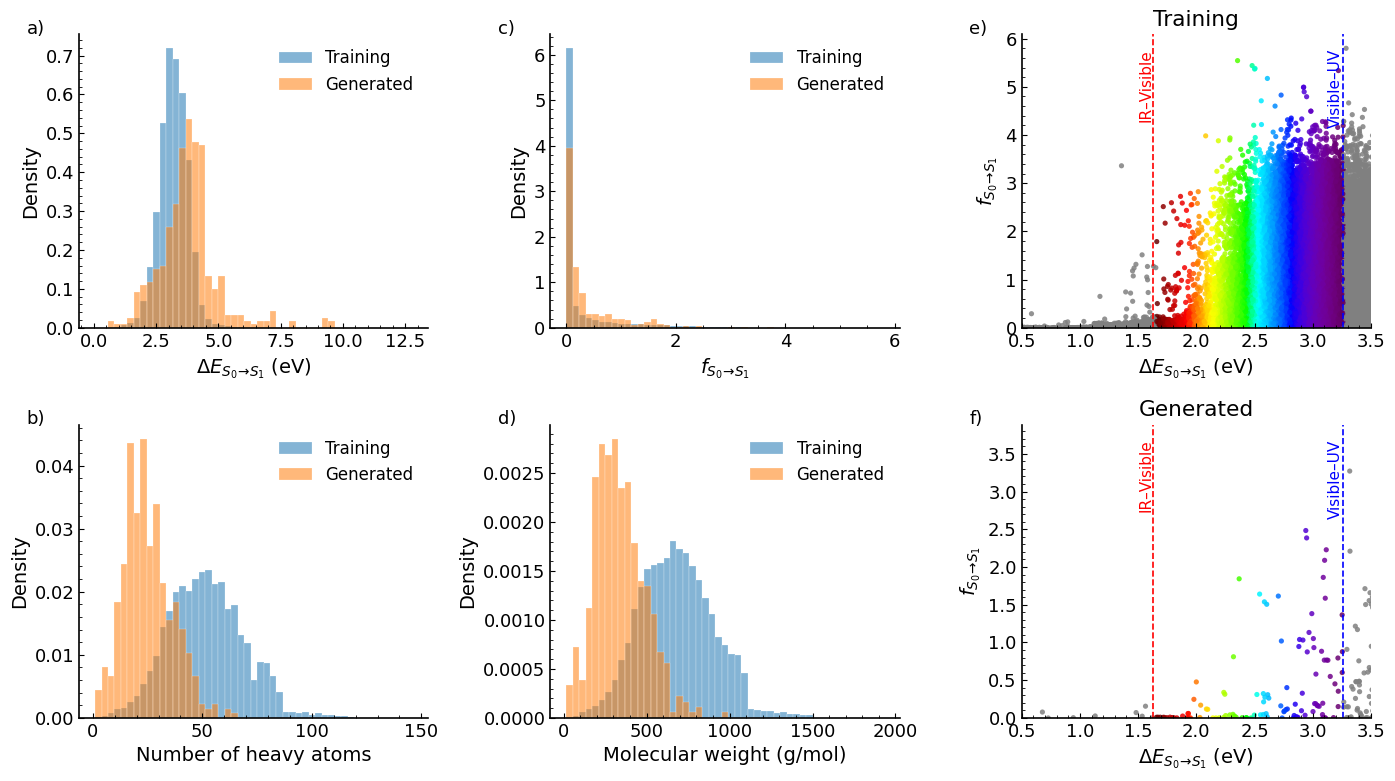

In [11]:


out_dir = base_path
out_dir.mkdir(parents=True, exist_ok=True)

train_filtered = train[train["strength"] <= 10].copy()
gen_filtered = gen[gen["osc_S1_SOC"] <= 10].copy()

plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True
})

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

def plot_hist(ax, data1, data2, xlabel):
    data1 = data1.dropna()
    data2 = data2.dropna()

    bins = np.linspace(
        min(data1.min(), data2.min()),
        max(data1.max(), data2.max()),
        50
    )

    ax.hist(
        data1, bins=bins, density=True, alpha=0.55,
        label="Training", edgecolor="white", linewidth=0.3
    )

    ax.hist(
        data2, bins=bins, density=True, alpha=0.55,
        label="Generated", edgecolor="white", linewidth=0.3
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.legend(frameon=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def add_region_lines(ax):
    ax.axvline(1.63, color="red", linestyle="--", linewidth=1.2)
    ax.axvline(3.26, color="blue", linestyle="--", linewidth=1.2)

    ymax = ax.get_ylim()[1]

    ax.text(
        1.63, ymax * 0.95, "IR–Visible",
        color="red", rotation=90,
        va="top", ha="right", fontsize=11
    )

    ax.text(
        3.26, ymax * 0.95, "Visible–UV",
        color="blue", rotation=90,
        va="top", ha="right", fontsize=11
    )

def scatter_panel(ax, df, col_E, col_f, title):
    data = df[[col_E, col_f]].dropna().copy()

    wavelength = 1239.841984 / data[col_E].values
    colors = [wavelength_to_rgb(w) for w in wavelength]

    ax.scatter(
        data[col_E],
        data[col_f],
        c=colors,
        s=14,
        alpha=0.85,
        edgecolors="none"
    )

    ax.set_title(title)
    ax.set_xlabel(r"$\Delta E_{S_0\!\to\!S_1}$ (eV)")
    ax.set_ylabel(r"$f_{S_0\!\to\!S_1}$")
    ax.set_xlim(0.5, 3.5)
    ax.set_ylim(bottom=0)

    add_region_lines(ax)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plot_hist(
    axes[0],
    train["absorption"],
    gen["E_S1_SOC(eV)"],
    r"$\Delta E_{S_0\!\to\!S_1}$ (eV)"
)

plot_hist(
    axes[1],
    train["strength"],
    gen["osc_S1_SOC"],
    r"$f_{S_0\!\to\!S_1}$"
)



scatter_panel(
    axes[2],
    train_filtered,
    col_E="absorption",
    col_f="strength",
    title="Training"
)

plot_hist(
    axes[3],
    train["heavy_atoms"],
    gen["heavy_atoms"],
    "Number of heavy atoms"
)

plot_hist(
    axes[4],
    train["molecular_weight"],
    gen["molecular_weight"],
    "Molecular weight (g/mol)"
)

scatter_panel(
    axes[5],
    gen_filtered,
    col_E="E_S1_SOC(eV)",
    col_f="osc_S1_SOC",
    title="Generated"
)

labels = ["a)", "c)", "e)", "b)", "d)", "f)"]
for ax, lab in zip(axes, labels):
    ax.text(
        -0.15, 1.05, lab,
        transform=ax.transAxes,
        fontsize=13,
        va="top"
    )

plt.tight_layout()

plt.savefig(out_dir / "training_vs_generated_distributions_and_scatter_panelled.pdf", bbox_inches="tight")
#plt.savefig(out_dir / "training_vs_generated_distributions_and_scatter_panelled.svg", bbox_inches="tight")
#plt.savefig(out_dir / "training_vs_generated_distributions_and_scatter_panelled.png", dpi=600, bbox_inches="tight")

plt.show()
plt.close()

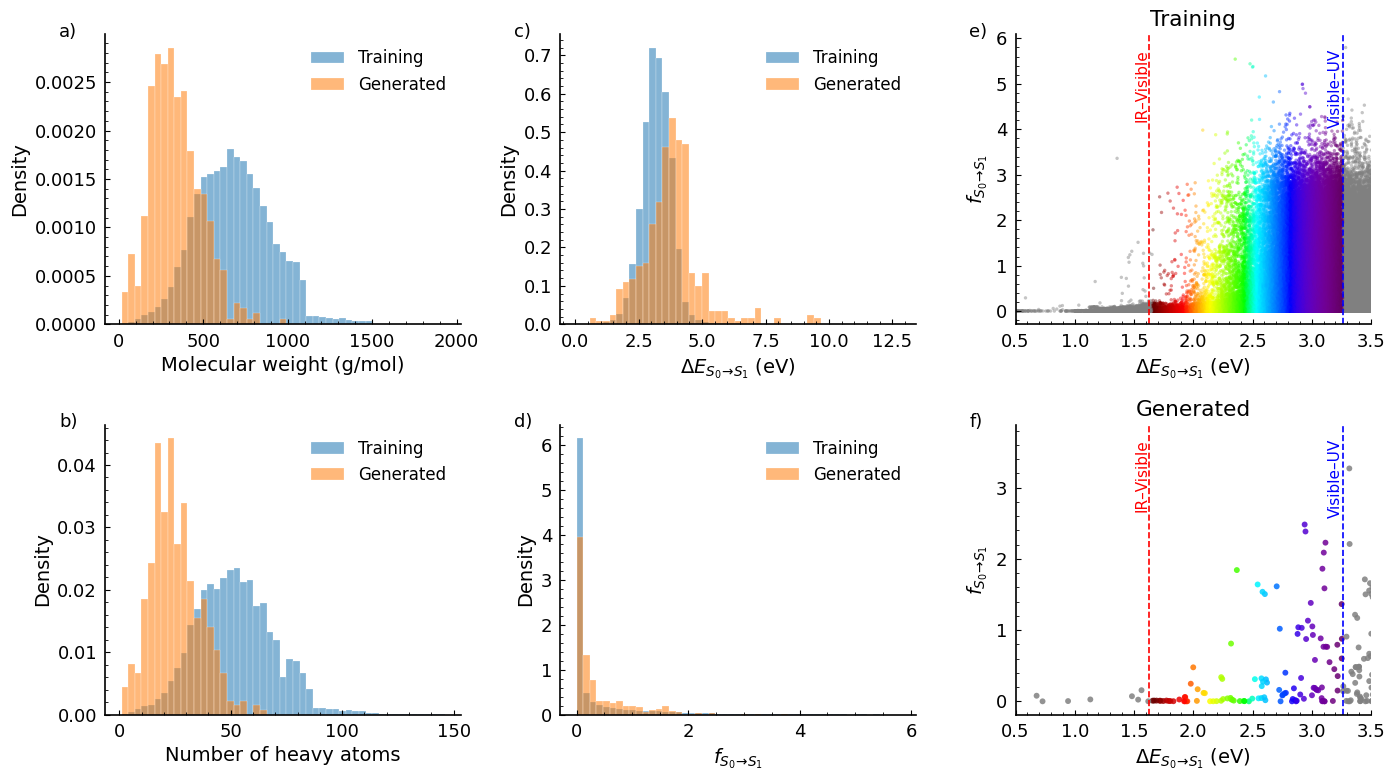

In [20]:
out_dir = base_path
out_dir.mkdir(parents=True, exist_ok=True)

train_filtered = train[train["strength"] <= 10].copy()
gen_filtered = gen[gen["osc_S1_SOC"] <= 10].copy()

plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True
})

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

def plot_hist(ax, data1, data2, xlabel):
    data1 = data1.dropna()
    data2 = data2.dropna()

    bins = np.linspace(
        min(data1.min(), data2.min()),
        max(data1.max(), data2.max()),
        50
    )

    ax.hist(
        data1, bins=bins, density=True, alpha=0.55,
        label="Training", edgecolor="white", linewidth=0.3
    )

    ax.hist(
        data2, bins=bins, density=True, alpha=0.55,
        label="Generated", edgecolor="white", linewidth=0.3
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.legend(frameon=False)

    ax.tick_params(axis="x", pad=6)
    ax.tick_params(axis="y", pad=6)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def add_region_lines(ax):
    ax.axvline(1.63, color="red", linestyle="--", linewidth=1.2)
    ax.axvline(3.26, color="blue", linestyle="--", linewidth=1.2)

    ymin, ymax = ax.get_ylim()

    ax.text(
        1.63, ymin + 0.95 * (ymax - ymin), "IR–Visible",
        color="red", rotation=90,
        va="top", ha="right", fontsize=11
    )

    ax.text(
        3.26, ymin + 0.95 * (ymax - ymin), "Visible–UV",
        color="blue", rotation=90,
        va="top", ha="right", fontsize=11
    )

def scatter_panel(ax, df, col_E, col_f, title):
    data = df[[col_E, col_f]].dropna().copy()

    wavelength = 1239.841984 / data[col_E].values
    colors = [wavelength_to_rgb(w) for w in wavelength]

    s = 6 if title == "Training" else 18
    alpha = 0.45 if title == "Training" else 0.85

    ax.scatter(
        data[col_E],
        data[col_f],
        c=colors,
        s=s,
        alpha=alpha,
        edgecolors="none",
        rasterized=True
    )

    ax.set_title(title)
    ax.set_xlabel(r"$\Delta E_{S_0\!\to\!S_1}$ (eV)")
    ax.set_ylabel(r"$f_{S_0\!\to\!S_1}$")
    ax.set_xlim(0.5, 3.5)

    ymax = data[col_f].max()
    ax.set_ylim(-0.05 * ymax, 1.05 * ymax)

    add_region_lines(ax)

    ax.tick_params(axis="x", pad=6)
    ax.tick_params(axis="y", pad=6)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plot_hist(
    axes[1],
    train["absorption"],
    gen["E_S1_SOC(eV)"],
    r"$\Delta E_{S_0\!\to\!S_1}$ (eV)"
)

plot_hist(
    axes[4],
    train["strength"],
    gen["osc_S1_SOC"],
    r"$f_{S_0\!\to\!S_1}$"
)

scatter_panel(
    axes[2],
    train_filtered,
    col_E="absorption",
    col_f="strength",
    title="Training"
)

plot_hist(
    axes[3],
    train["heavy_atoms"],
    gen["heavy_atoms"],
    "Number of heavy atoms"
)

plot_hist(
    axes[0],
    train["molecular_weight"],
    gen["molecular_weight"],
    "Molecular weight (g/mol)"
)

scatter_panel(
    axes[5],
    gen_filtered,
    col_E="E_S1_SOC(eV)",
    col_f="osc_S1_SOC",
    title="Generated"
)

labels = ["a)", "c)", "e)", "b)", "d)", "f)"]
for ax, lab in zip(axes, labels):
    ax.text(
        -0.13, 1.04, lab,
        transform=ax.transAxes,
        fontsize=13,
        va="top"
    )

plt.tight_layout()

plt.savefig(
    out_dir / "training_vs_generated_distributions_and_scatter_panelled.pdf",
    bbox_inches="tight"
)
# plt.savefig(out_dir / "training_vs_generated_distributions_and_scatter_panelled.svg", bbox_inches="tight")
# plt.savefig(out_dir / "training_vs_generated_distributions_and_scatter_panelled.png", dpi=600, bbox_inches="tight")

plt.show()
plt.close()

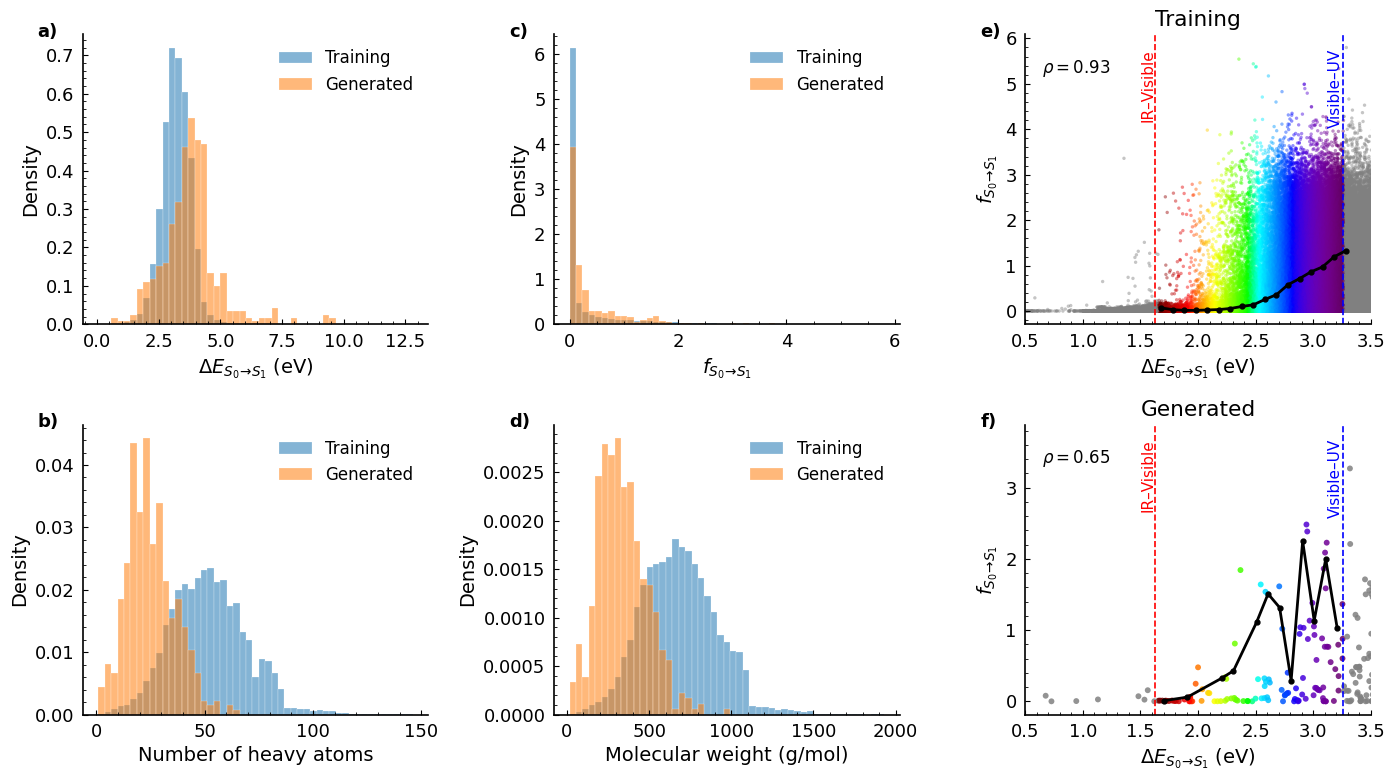

In [14]:
from scipy.stats import spearmanr

out_dir = base_path
out_dir.mkdir(parents=True, exist_ok=True)

train_filtered = train[train["strength"] <= 10].copy()
gen_filtered = gen[gen["osc_S1_SOC"] <= 10].copy()

# -----------------------
# Envelope parameters
# -----------------------
LOWER_BOUND = 1.63
UPPER_BOUND = 3.26
QUANTILE = 0.90
BIN_WIDTH = 0.1
MIN_BIN_SIZE = 5

plt.rcParams.update({
    "font.size": 13,
    "axes.labelsize": 14,
    "legend.fontsize": 12,
    "axes.linewidth": 1.2,
    "xtick.direction": "in",
    "ytick.direction": "in",
    "xtick.minor.visible": True,
    "ytick.minor.visible": True
})

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

def plot_hist(ax, data1, data2, xlabel):
    data1 = data1.dropna()
    data2 = data2.dropna()

    bins = np.linspace(
        min(data1.min(), data2.min()),
        max(data1.max(), data2.max()),
        50
    )

    ax.hist(
        data1, bins=bins, density=True, alpha=0.55,
        label="Training", edgecolor="white", linewidth=0.3
    )

    ax.hist(
        data2, bins=bins, density=True, alpha=0.55,
        label="Generated", edgecolor="white", linewidth=0.3
    )

    ax.set_xlabel(xlabel)
    ax.set_ylabel("Density")
    ax.legend(frameon=False)

    ax.tick_params(axis="x", pad=6)
    ax.tick_params(axis="y", pad=6)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

def add_region_lines(ax):
    ax.axvline(1.63, color="red", linestyle="--", linewidth=1.2)
    ax.axvline(3.26, color="blue", linestyle="--", linewidth=1.2)

    ymin, ymax = ax.get_ylim()

    ax.text(
        1.63, ymin + 0.95 * (ymax - ymin), "IR–Visible",
        color="red", rotation=90,
        va="top", ha="right", fontsize=11
    )

    ax.text(
        3.26, ymin + 0.95 * (ymax - ymin), "Visible–UV",
        color="blue", rotation=90,
        va="top", ha="right", fontsize=11
    )

def compute_envelope(data, col_E, col_f):
    data = data[[col_E, col_f]].dropna().copy()
    data = data[
        (data[col_E] >= LOWER_BOUND) &
        (data[col_E] <= UPPER_BOUND) &
        (data[col_f] >= 0)
    ]

    bin_centers = []
    envelope_values = []

    bin_edges = np.arange(
        data[col_E].min(),
        data[col_E].max() + BIN_WIDTH,
        BIN_WIDTH
    )

    for left, right in zip(bin_edges[:-1], bin_edges[1:]):
        in_bin = data[(data[col_E] >= left) & (data[col_E] < right)]

        if len(in_bin) >= MIN_BIN_SIZE:
            bin_centers.append((left + right) / 2)
            envelope_values.append(np.quantile(in_bin[col_f], QUANTILE))

    return np.array(bin_centers), np.array(envelope_values)

def add_envelope(ax, df, col_E, col_f):
    x_env, y_env = compute_envelope(df, col_E, col_f)

    if len(x_env) > 0:
        ax.plot(
            x_env,
            y_env,
            color="black",
            linewidth=2.0,
            marker="o",
            markersize=3.5,
            label="90th percentile"
        )

    if len(x_env) > 3:
        rho, _ = spearmanr(x_env, y_env)

        ax.text(
            0.05, 0.92,
            rf"$\rho={rho:.2f}$",
            transform=ax.transAxes,
            fontsize=12,
            ha="left",
            va="top"
        )

def scatter_panel(ax, df, col_E, col_f, title):
    data = df[[col_E, col_f]].dropna().copy()

    wavelength = 1239.841984 / data[col_E].values
    colors = [wavelength_to_rgb(w) for w in wavelength]

    s = 6 if title == "Training" else 18
    alpha = 0.45 if title == "Training" else 0.85

    ax.scatter(
        data[col_E],
        data[col_f],
        c=colors,
        s=s,
        alpha=alpha,
        edgecolors="none",
        rasterized=True
    )

    ax.set_title(title)
    ax.set_xlabel(r"$\Delta E_{S_0\!\to\!S_1}$ (eV)")
    ax.set_ylabel(r"$f_{S_0\!\to\!S_1}$")
    ax.set_xlim(0.5, 3.5)

    ymax = data[col_f].max()
    ax.set_ylim(-0.05 * ymax, 1.05 * ymax)

    add_region_lines(ax)
    add_envelope(ax, df, col_E, col_f)

    ax.tick_params(axis="x", pad=6)
    ax.tick_params(axis="y", pad=6)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plot_hist(
    axes[0],
    train["absorption"],
    gen["E_S1_SOC(eV)"],
    r"$\Delta E_{S_0\!\to\!S_1}$ (eV)"
)

plot_hist(
    axes[1],
    train["strength"],
    gen["osc_S1_SOC"],
    r"$f_{S_0\!\to\!S_1}$"
)

scatter_panel(
    axes[2],
    train_filtered,
    col_E="absorption",
    col_f="strength",
    title="Training"
)

plot_hist(
    axes[3],
    train["heavy_atoms"],
    gen["heavy_atoms"],
    "Number of heavy atoms"
)

plot_hist(
    axes[4],
    train["molecular_weight"],
    gen["molecular_weight"],
    "Molecular weight (g/mol)"
)

scatter_panel(
    axes[5],
    gen_filtered,
    col_E="E_S1_SOC(eV)",
    col_f="osc_S1_SOC",
    title="Generated"
)

labels = ["a)", "c)", "e)", "b)", "d)", "f)"]
for ax, lab in zip(axes, labels):
    ax.text(
        -0.13, 1.04, lab,
        transform=ax.transAxes,
        fontsize=13,
        fontweight="bold",
        va="top"
    )

plt.tight_layout()

plt.savefig(
    out_dir / "training_vs_generated_distributions_and_scatter_spearman_panelled.pdf",
    bbox_inches="tight"
)

plt.show()
plt.close()

# plot histrograms

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

gen = pd.read_csv(base_path / "generated_validation_data.csv")
# --- compute median grids ---
abs_bins = sorted(gen['abs_token'].unique())
str_bins = sorted(gen['str_token'].unique())

grid_E = np.zeros((len(str_bins), len(abs_bins)))
grid_f = np.zeros((len(str_bins), len(abs_bins)))

for i, s in enumerate(str_bins):
    for j, a in enumerate(abs_bins):
        subset = gen[
            (gen['abs_token'] == a) &
            (gen['str_token'] == s)
        ]
        grid_E[i, j] = subset['E_S1(eV)'].median()
        grid_f[i, j] = subset['f_osc'].median()

# --- plotting ---
fig, axes = plt.subplots(2, 1, figsize=(5, 8))

# panel a) absorption
im0 = axes[0].imshow(grid_E, origin='lower', aspect='auto')
cbar0 = fig.colorbar(im0, ax=axes[0])
cbar0.set_label(r'Median $\Delta E_{S_0\to S_1}$ (eV)')

axes[0].set_xticks(range(len(abs_bins)))
axes[0].set_yticks(range(len(str_bins)))
axes[0].set_xlabel('Absorption token')
axes[0].set_ylabel('Strength token')

# panel label
axes[0].text(-0.15, 1.05, 'a)', transform=axes[0].transAxes,
             fontsize=12, fontweight='bold', va='top')

# panel b) oscillator strength
im1 = axes[1].imshow(grid_f, origin='lower', aspect='auto')
cbar1 = fig.colorbar(im1, ax=axes[1])
cbar1.set_label(r'Median $f_{S_0\to S_1}$')

axes[1].set_xticks(range(len(abs_bins)))
axes[1].set_yticks(range(len(str_bins)))
axes[1].set_xlabel('Absorption token')
axes[1].set_ylabel('Strength token')

# panel label
axes[1].text(-0.15, 1.05, 'b)', transform=axes[1].transAxes,
             fontsize=12, fontweight='bold', va='top')

plt.tight_layout()
plt.savefig('median_heatmaps_panelled.pdf', dpi=300, bbox_inches='tight')
plt.show()

KeyError: 'abs_token'